# PYTHON İLE VERİ BİLİMİNE GİRİŞ FİNAL PROJESİ
## Proje Adı: Öğrenci Performans Analizi ve Tahminlemesi  
## Hazırlayan: Salih Karakuş  
## Öğrenci No: 221001065

## Veri Seti Hikayesi
### Bu veri seti, öğrencilerin akademik performanslarını etkileyen çeşitli faktörleri içermektedir. Amacımız; çalışma saatleri, uyku düzeni ve ders dışı etkinlikler gibi parametrelerin öğrencinin nihai performans indeksi üzerindeki etkisini analiz etmek ve bir tahmin modeli oluşturmaktır.

## Sütun Açıklamaları:
### Hours Studied: Günlük çalışma saati.
### Previous Scores: Önceki sınav sonuçları.
### Extracurricular Activities: Ders dışı etkinlikler (Evet/Hayır).
### Sleep Hours: Günlük uyku süresi.
### Performance Index: Hedef değişkenimiz (Öğrencinin başarı puanı).

![Veriseti Görseli](db.png)

In [32]:
import pandas as pd     # pandası ekledik
import numpy as np       # numpyi ekledik
import matplotlib.pyplot as plt  # grafiklerler için matplotlib
import seaborn as sns    # daha süslü ve gelişmiş grafikler için seaborn

# Grafiklerin notebook içinde görünmesini sağlar
%matplotlib inline 

print("Kütüphaneler başarıyla yüklendi")

Kütüphaneler başarıyla yüklendi


In [33]:
# Veri setini yükleyelim
df = pd.read_csv('StudentPerformance.csv')

# Verinin ilk 5 satırına bir bakalım
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [34]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [36]:
# Sayısal değişkenlerin istatistiklerini görüntüleyelim
print("Sayısal Değişkenlerin Özeti:")
display(df.describe())

# Kategorik değişkenin özeti (ders dışı etkinlik değişkenini inceleyelim)
print("\nKategorik Değişken Özeti:")
display(df.describe(include=['O']))

Sayısal Değişkenlerin Özeti:


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000



Kategorik Değişken Özeti:


,Extracurricular Activities
count,10000
unique,2
top,No
freq,5052


In [37]:
# Her sütunda kaç tane boş (NaN) değer var bakalım
print("Eksik Veri Sayısı:")
print(df.isnull().sum())

Eksik Veri Sayısı:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


Yapılan inceleme sonucunda veri setinde eksik (NaN) değer saptanmadı. Bu durum veri setinin ön işleme aşaması için oldukça tutarlı ve güvenilir olduğunu göstermekte bizim için.

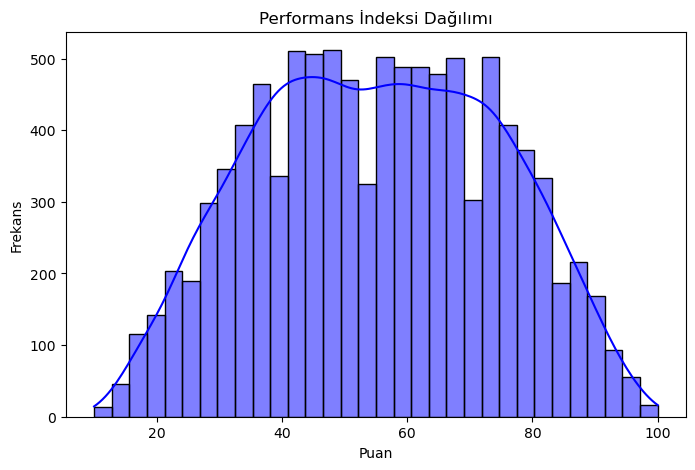

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Performance Index'], kde=True, color='blue')
plt.title('Performans İndeksi Dağılımı')
plt.xlabel('Puan')
plt.ylabel('Frekans')
plt.show()

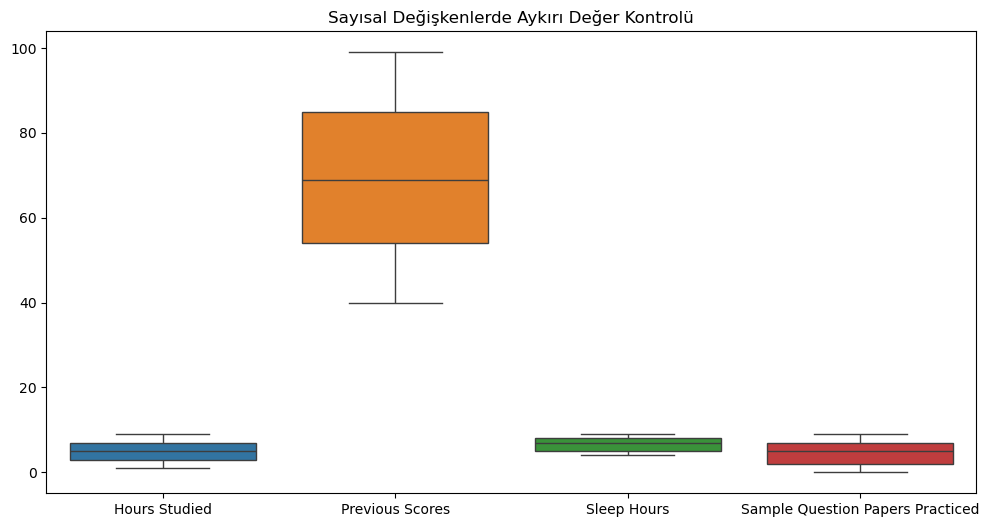

In [39]:
# Sayısal sütunları seçelim
cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

# Aykırı değerleri görmek için boxplot çizdirelim
plt.figure(figsize=(12,6))
sns.boxplot(data=df[cols])
plt.title('Sayısal Değişkenlerde Aykırı Değer Kontrolü')
plt.show()

In [40]:
# Sayısal bir sütun için (örneğin Previous Scores) aykırı değer varmı kontrol edelim
Q1 = df['Previous Scores'].quantile(0.25)
Q3 = df['Previous Scores'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

aykiri_veriler = df[(df['Previous Scores'] < alt_sinir) | (df['Previous Scores'] > ust_sinir)]
print(f"Previous Scores için aykırı veri sayısı: {len(aykiri_veriler)}")

Previous Scores için aykırı veri sayısı: 0


In [41]:
# Yes -> 1, No -> 0 olacak şekilde dönüştürüyoruz
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Kontrol edelim
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [42]:
from scipy import stats

grup_evet = df[df['Extracurricular Activities'] == 1]['Performance Index']
grup_hayir = df[df['Extracurricular Activities'] == 0]['Performance Index']

t_stat, p_value = stats.ttest_ind(grup_evet, grup_hayir)

print(f"T-İstatistiği: {t_stat}")
print(f"P-Değeri: {p_value}")

if p_value < 0.05:
    print("Sonuç: P-değeri 0.05'ten küçük olduğu için H0 reddedilir. İki grup arasında anlamlı bir fark VARDIR.")
else:
    print("Sonuç: P-değeri 0.05'ten büyük olduğu için H0 reddedilemez. İki grup arasında anlamlı bir fark YOKTUR.")

T-İstatistiği: 2.452987248811042
P-Değeri: 0.01418449156855449
Sonuç: P-değeri 0.05'ten küçük olduğu için H0 reddedilir. İki grup arasında anlamlı bir fark VARDIR.


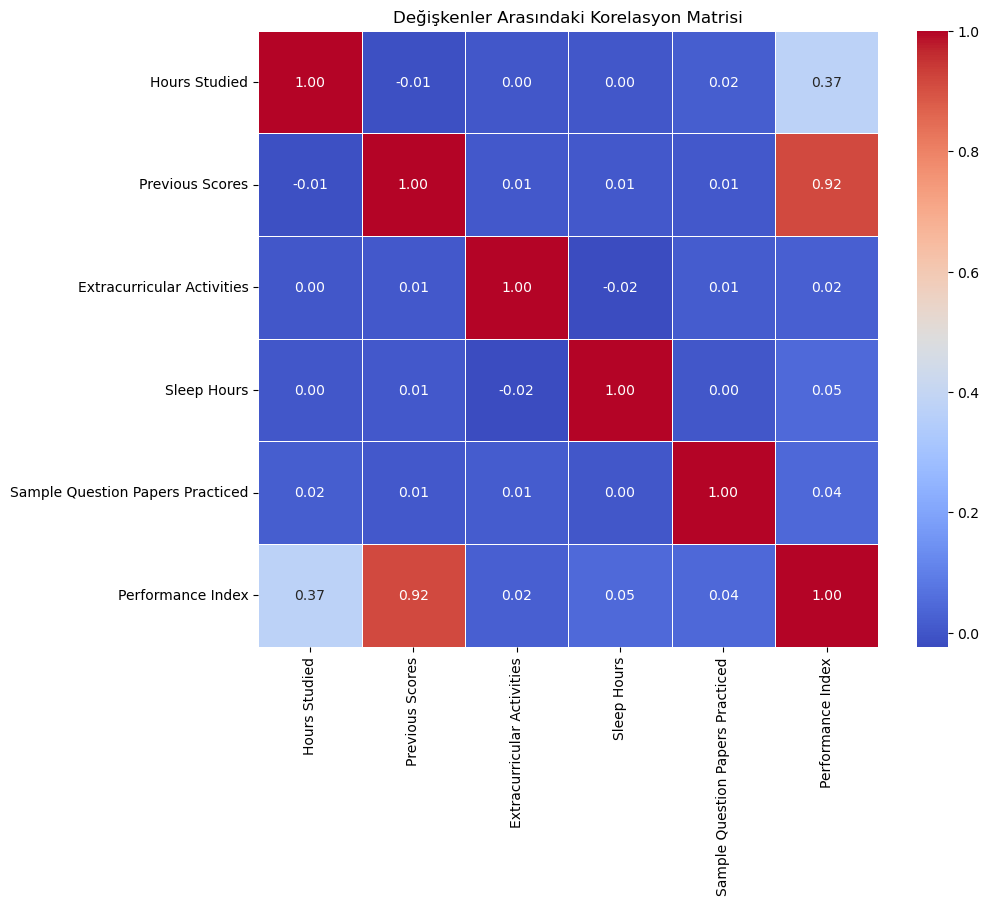

In [43]:
# Sadece sayısal sütunlar arasındaki ilişkiyi hesaplayalım
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Isı haritasını (Heatmap) çizdirelim
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Değişkenler Arasındaki Korelasyon Matrisi')
plt.show()

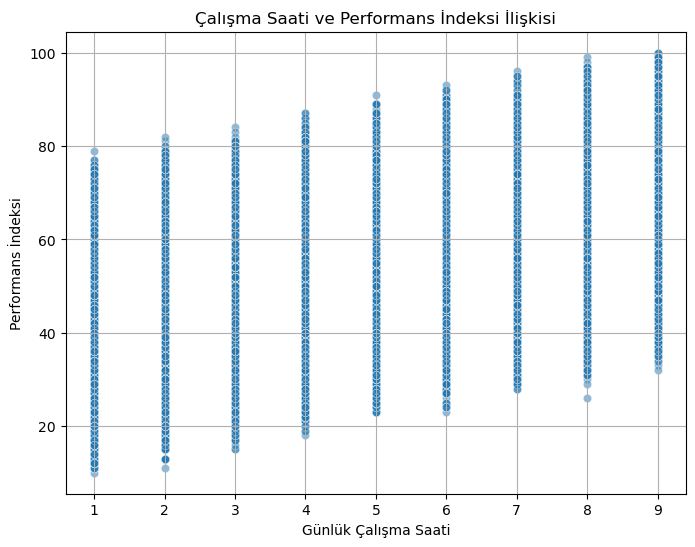

In [44]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Hours Studied', y='Performance Index', data=df, alpha=0.5)
plt.title('Çalışma Saati ve Performans İndeksi İlişkisi')
plt.xlabel('Günlük Çalışma Saati')
plt.ylabel('Performans İndeksi')
plt.grid(True)
plt.show()

In [45]:
from sklearn.model_selection import train_test_split

# Hedef değişkenimiz (y) ve bağımsız değişkenlerimiz (X)
X = df.drop('Performance Index', axis=1) # Performans indeksi hariç her şey
y = df['Performance Index']              # Sadece performans indeksi

# Veriyi bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

Eğitim seti boyutu: (8000, 5)
Test seti boyutu: (2000, 5)


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Modeli oluşturalım
model = LinearRegression()

# 2. Modeli eğitme (Eğitim verilerini modele veriyoruz)
model.fit(X_train, y_train)

# 3. Tahmin yapma (Modelin hiç görmediği test verilerini veriyoruz)
y_pred = model.predict(X_test)

print("Model başarıyla eğitildi ve tahminler yapıldı")

Model başarıyla eğitildi ve tahminler yapıldı


In [47]:
# Başarı metriklerini hesaplayalım
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Ortalama Kare Hata (MSE): {mse:.2f}")
print(f"Modelin Başarı Skoru (R2): {r2:.4f}")

Ortalama Kare Hata (MSE): 4.08
Modelin Başarı Skoru (R2): 0.9890


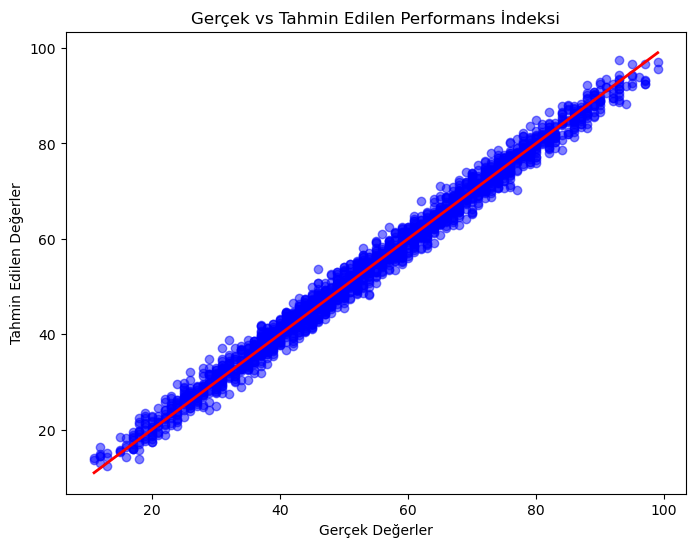

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Edilen Değerler')
plt.title('Gerçek vs Tahmin Edilen Performans İndeksi')
plt.show()

## Sonuç ve Değerlendirme: > Bu projede öğrenci performansını etkileyen faktörler analiz edilmiştir. Yapılan analizler sonucunda "Geçmiş Sınav Notları"nın performans üzerinde en belirleyici etken olduğu (0.92 korelasyon) saptanmıştır. Geliştirilen Lineer Regresyon modeli, %98'in üzerinde bir açıklayıcılık oranı ($R^2$) ile öğrenci performansını başarıyla tahmin edebilmektedir.